# NoSQL and Object Storage

This notebook covers two types of non-relational (NoSQL) data stores:
- **Redis** — an in-memory key-value store used for fast reads, caching, and session data
- **Google Cloud Storage (GCS)** — an object store used for storing large files like images, videos, and datasets

---

## How to use this notebook

| Section | Type | Description |
|---|---|---|
| Part 1: Redis | **Core** | Connect to Redis and work with key-value pairs, lists, and hashes |
| Part 2: Google Cloud Storage | **Core** | Connect to GCS, read bucket and blob metadata |
| Part 3: Redis Account Setup | *Optional* | Step-by-step guide to create a free Redis account |
| Part 4: GCS Personal Account | *Optional* | Connect GCS using your own Google account |

> **Prerequisite:** Complete Part 3 (Redis account setup) before running Part 1.

---
## Why NoSQL?

Relational databases (SQL) store data in structured tables with strict schemas. They work well for most applications, but sometimes you need something different:

| Use Case | Better Choice | Why |
|---|---|---|
| Cache user sessions | Redis (key-value) | Millisecond reads, data lives in memory |
| Store user profiles | MongoDB (document) | Flexible, schema-free JSON documents |
| Store images or datasets | GCS (object store) | Designed for large unstructured files |
| Social graph (followers) | Neo4j (graph) | Relationships are first-class citizens |

In this lesson we focus on **key-value** (Redis) and **object storage** (GCS) — two of the most common NoSQL patterns in data engineering.

---
# Part 1: Redis (Core)

## What is Redis?

Redis stores data as **key-value pairs** entirely in memory (RAM), which makes it extremely fast — most operations run in O(1) constant time, the same complexity as looking up a value in a Python dictionary.

**Common uses:**
- Caching database query results
- Storing user session tokens
- Real-time leaderboards and counters
- Message queues between services

Unlike a Python dict, Redis:
- Persists data across restarts (optional)
- Can be shared across multiple servers
- Supports expiry (TTL) on keys
- Has built-in data types: strings, lists, hashes, sets, sorted sets

We will be connecting to a hosted Redis database on Redis Cloud (free tier).

## 💡 Real-world Business Use Cases of Redis

#### 1. Discord

**Product**: Global game & social chat platform

**Redis usage:**
- Use **List** to store chat history.
- Use **Hash** to cache user profile information.
- Use **String** to record online/offline status.

**Why use Redis**: Support millions of online users with ultra-fast message response.

---

#### 2. League of Legends (Riot Games)

**Product**: Popular global MOBA game

**Redis usage:**
- Use **Sorted Set (ZSet)** to build real-time game rank leaderboards. Update player scores and query top players instantly.

**Why use Redis**: Real-time ranking for millions of players; database cannot handle fast sorting.

---

#### 3. GitHub

**Product**: World's largest code hosting platform

**Redis usage:**
- Use **String** to count repository stars and forks.
- Use **Hash** to cache repository basic info.
- Use **List** as event message queue.

**Why use Redis**: Reduce database pressure and make pages load instantly.

---

#### 4. Stripe

**Product**: Global online payment service

**Redis usage:**
- Use **String** with expiration for API rate limiting.
- Use **Hash** to cache temporary payment session data.
- Use **Redis distributed lock** to avoid duplicate payments.

**Why use Redis**: Handle high-concurrency payment requests with low latency and safety.

---

#### 5. E-Commerce (e.g., Amazon)

**Product**: Online shopping platform

**Redis usage:**
- Use **Hash** to cache product details and inventory status.
- Use **Sorted Set (ZSet)** to implement real-time product recommendation and ranking based on user behavior.
- Use **String** to manage user sessions and shopping carts.

**Why use Redis**: Provide fast access to product information and personalized recommendations, ensuring a smooth shopping experience even during peak traffic times.

## 1.1 Connecting to Redis

> **First time?** Complete **Part 3** (Redis Account Setup) to get your connection credentials, then come back here.

### Storing credentials safely with `.env`

Never hardcode passwords in your notebook — they can accidentally be committed to Git and exposed publicly. Instead, store them in a `.env` file:
- The `.env` file lives **outside** your notebook directory
- It is listed in `.gitignore` so it is never synced to GitHub
- `python-dotenv` loads those values into `os.environ` at runtime

Run the cell below **once** to create the `.env` template file:

In [1]:
# Paste your code from Step 5 above below this line
# -------------------------------------------------

# Please delete the settings below after .env file is created and password configured

"""Basic connection example.
"""

import redis

r = redis.Redis(
    host='redis-18504.crce285.us-east-1-4.ec2.cloud.redislabs.com',
    port=18504,
    decode_responses=True,
    username="default",
    password="GO3huHM9FU2v9GlukhzggGGgpqljM80n",
)

success = r.set('foo', 'bar')
# True

result = r.get('foo')
print(result)
# >>> bar


bar


After running the cell above, open the `.env` file and replace each `XXXXX` with the values from your Redis Cloud dashboard:

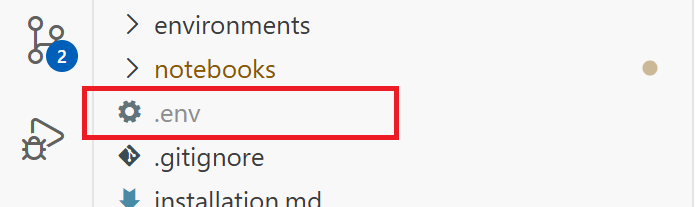

> **You only need to create the template once.** Skip the cell above on future runs.

### Paste Connection Code from Part 3

After setting up your Redis account (Part 3), paste the Python connection snippet here to verify your credentials before adding them to `.env`.

In [ ]:
# Paste your connection code from Part 3 (Step 5) here — for testing only.
# Once confirmed, copy the host, port, and password into your .env file,
# then delete this code to avoid committing your password to Git.

# Paste below this line:

> **Important:** Your connection secrets including the password are yours. Do not share them. Do not sync this information to a public repository. Store your credentials only in the `.env` file (which is excluded from Git by `.gitignore`).

### Connect using your `.env` credentials

Once your `.env` file is filled in, run this cell to connect. You can use this as your starting point in future sessions.

In [1]:
import os
import redis
from dotenv import load_dotenv

# load_dotenv() reads the ../.env file and populates os.environ
# This means your password never appears as a literal string in this notebook
load_dotenv()

REDIS_HOST='redis-18504.crce285.us-east-1-4.ec2.cloud.redislabs.com'
REDIS_PORT='18504' 
REDIS_USERNAME='default'
REDIS_PASSWORD='GO3huHM9FU2v9GlukhzggGGgpqljM80n'

# decode_responses=True makes Redis return Python strings instead of raw bytes
r = redis.Redis(
    host=REDIS_HOST,
    port=REDIS_PORT,
    decode_responses=True,
    username=REDIS_USERNAME,
    password=REDIS_PASSWORD,
)

# A quick smoke test: set a key and read it back
r.set('connection_test', 'ok')
result = r.get('connection_test')
print(f"Connection status: {result}")  # Should print: Connection status: ok

Connection status: ok


> **Important:** If your connection is working using `.env`, please delete the code you pasted in the **Paste Connection Code** cell above to avoid accidentally committing your password.

---
## 1.2 String Operations: `set` and `get`

The simplest Redis data type is a **string** — any text or number stored under a key.

- `r.set(key, value)` — stores a value; overwrites if the key exists
- `r.get(key)` — retrieves the value; returns `None` if the key does not exist

Think of it like a Python dict that lives on a remote server.

In [2]:
# Store a string value under the key 'name'
r.set('name', 'Aaron')

# Retrieve it
print(r.get('name'))   # Aaron

Aaron


In [3]:
# set() is also how you UPDATE an existing key — there is no separate update command
r.set('name', 'Bob')
print(r.get('name'))   # Bob

Bob


> **Exercise 1:** Set a key `age` with the value `20`, then read it back.

In [4]:
# Your code here to set a key `age` with value of `20` and then read the value back
r.set('age',20)
r.get('age')

'20'

---
## 1.3 Batch Operations: `mset` and `mget`

When you need to set or get multiple keys at once, use `mset` / `mget` instead of calling `set` / `get` in a loop.

**Why?** Each Redis call is a round-trip over the network. Batching reduces latency significantly when working with many keys.

In [5]:
# mset accepts a dictionary — sets all keys in a single network call
r.mset({
    'name': 'John',
    'age': 30,
})

# mget returns a list of values in the same order as the keys you requested
values = r.mget('name', 'age')
print(values)   # ['John', '30']

['John', '30']


---
## 1.4 Lists: `rpush` and `lindex`

A Redis **list** is an ordered sequence of strings stored under a single key.

- `rpush(key, *values)` — appends one or more values to the **right** end of the list ("r" = right)
- `lindex(key, index)` — retrieves the element at a given index (0-based), like `list[i]` in Python
- `lrange(key, start, end)` — retrieves a slice of the list; use `-1` as end to get all elements

In [6]:
# Push three names onto the list in one call
r.rpush('names', 'Aaron', 'Bob', 'Charlie')

# Retrieve elements by index (zero-based)
print(r.lindex('names', 0))   # Aaron
print(r.lindex('names', 1))   # Bob
print(r.lindex('names', 2))   # Charlie

Matthew
Mark
Luke


> **Exercise 2:** Push 3 names into the list called `names`. Then read the full list back using `lrange`.

In [7]:
# Your code here to insert 3 names into the list above and then read the list back



print(r.lrange('names', 0, -1))

['Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie']


---
## 1.5 Hashes: `hset`, `hget`, `hgetall`

A Redis **hash** is a collection of field-value pairs stored under a single key — similar to a Python dictionary nested inside another dictionary.

Use hashes when you want to represent a single object (e.g. a user profile) without serialising it to JSON.

| Command | Description |
|---|---|
| `hset(key, mapping={...})` | Create or update the hash at `key` |
| `hget(key, field)` | Get the value of one field |
| `hgetall(key)` | Get all field-value pairs as a dict |

In [8]:
# Store a user object as a hash
# The top-level key is the person's name; fields are their attributes
r.hset(
    'zane lim',
    mapping={
        'age': 21,
        'email': 'zl@gmail.com',
        'hobby': 'coding',
    },
)

0

In [9]:
# Fetch a single field — efficient when you only need one attribute
print(r.hget('zane lim', 'email'))   # zl@gmail.com

zl@gmail.com


In [10]:
# Fetch the entire object as a Python dict
profile = r.hgetall('zane lim')
print(profile)
# {'age': '21', 'email': 'zl@gmail.com', 'hobby': 'coding'}

{'age': '21', 'email': 'zl@gmail.com', 'hobby': 'coding'}


> **Exercise 3:** Create a hash with your own name as the key, and fields `age`, `email`, and `hobby`. Then retrieve the full object with `hgetall`.

In [11]:
# Your code here to insert 3 names into the list above and then read the list back
r.rpush("names", "Matthew", "Mark", "Luke", "John")


print(r.lrange("names", 0, -1)) 

['Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John', 'Aaron', 'Bob', 'Charlie', 'Matthew', 'Mark', 'Luke', 'John']


---
## Redis Summary

| Data Type | Commands | Best For |
|---|---|---|
| String | `set`, `get`, `mset`, `mget` | Single values, counters, flags |
| List | `rpush`, `lindex`, `lrange` | Ordered sequences, queues |
| Hash | `hset`, `hget`, `hgetall` | Objects / records with multiple fields |


> **Tip:** Always shut down your Redis cluster when not in use to avoid charges. In the Redis Cloud dashboard, navigate to your database and click **Delete**. See this [screenshot](../assets/redis_terminate_db.png) for a guide.

---
# Part 2: Google Cloud Storage (Core)

## 💡 Real-world Business Use Cases of GCS

#### 1. Uber (Ridesharing) – Real-Time Data Lake & Analytics

**Verified**: Uber officially confirmed migrating its petabyte-scale data lake to GCS for batch analytics and AI/ML training.

**Scenario**: Stores global trip logs, GPS streams, and order records as **GCS objects** in partitioned Parquet/ORC format, serving Spark/Presto queries and ML model training.

**Redis vs GCS:**
- Redis: `SET user:1001 '{"name":"Alice","city":"New York"}'` (hot user data)
- GCS: `gsutil cp trip_logs_20251231.parquet gs://uber-data-lake/raw/trip/2025/12/31/` (cold, massive historical data)

---

#### 2. Snap Inc. (Snapchat) – User-Generated Media Storage

**Verified**: Snap committed $2B to GCP over 5 years; GCS stores billions of daily photos/videos and user "Memories".

**Scenario**: All user uploads (Snaps, Stories, Memories) are saved as **GCS objects** with lifecycle policies (30-day standard → archive → cold storage).

**Redis vs GCS:**
- Redis: `INCR post:9999:likes` (hot engagement counters)
- GCS: `gsutil cp user_12345_video.mp4 gs://snap-media-bucket/user_content/12345/` (large, long-term media files)

---

#### 3. Spotify (Music Streaming) – Media Library & Metadata

**Verified**: Spotify uses GCS for its global music catalog, podcast files, and user playlists.

**Scenario**: Stores millions of audio tracks (MP3/FLAC), cover art, and podcast episodes as **GCS objects**, integrated with CDN for low-latency streaming.

**Redis vs GCS:**
- Redis: `SET user:789:current_song 'track:5678'` (hot playback state)
- GCS: `gsutil cp track_5678.flac gs://spotify-catalog/music/5678/` (static, high-quality media)

---

#### 4. HSBC (Global Banking) – Compliance Archiving & Risk Data

**Verified**: GCP financial services case studies confirm HSBC uses GCS for regulated data retention (7–10 years).

**Scenario**: Stores transaction records, trade documents, and compliance reports as **immutable GCS objects** with versioning and retention locks for audit trails.

**Redis vs GCS:**
- Redis: `DECR account:555:balance 1000` (hot real-time transactions)
- GCS: `gsutil cp trade_20251231_001.xml gs://hsbc-archive/trade_docs/2025/12/31/` (cold, legally required archives)

---

#### 5. The New York Times (Media) – Digital Content & Backups

**Verified**: NYT migrated its entire digital archive (160+ years of articles, images, videos) to GCS.

**Scenario**: Stores historical news assets, multimedia content, and disaster recovery backups as **GCS objects** with multi-region replication for durability.

**Redis vs GCS:**
- Redis: `INCR article:1234:views` (hot real-time engagement)
- GCS: `gsutil cp 1945_victory_edition.pdf gs://nyt-archive/1945/05/08/` (cold, permanent historical records)

---

### Key Takeaway

| | Redis | GCS |
|---|---|---|
| Data size | Small | Large (GB–PB) |
| Access speed | Milliseconds | Seconds |
| Best for | Hot data: sessions, counters, caches | Cold data: media, archives, datasets |

## What is Object Storage?

Object storage is designed for storing large, unstructured data — images, videos, audio files, CSVs, Parquet datasets, model weights. Unlike a filesystem, there are no real folders: objects are stored in **buckets** with a flat namespace (the `/` in object names is just part of the name, not a real directory).

**Google Cloud Storage (GCS)** is Google's object store. Key concepts:

| Concept | Description |
|---|---|
| **Project** | Every GCS resource belongs to a Google Cloud Project — your overall cloud workspace |
| **Bucket** | A globally unique container; all objects live inside a bucket |
| **Object / Blob** | The file itself, plus metadata (size, content-type, URL) |
| **Storage class** | Controls cost vs. access speed (Standard, Nearline, Coldline) |
| **Location** | The region where data is physically stored — affects latency and compliance |

**Core concept in one sentence:** GCS = Online storage → create **Buckets** (folders) → put **Objects** (files) inside → **metadata** describes each file.

We will use the public [Landsat Collection 1](https://console.cloud.google.com/storage/browser/gcp-public-data-landsat) dataset, which requires no authentication.

## 2.1 Connecting with an Anonymous Client

Public GCS buckets can be accessed without credentials using `create_anonymous_client()`.

This is useful for reading open datasets without needing a Google account.

> **Note:** If you see an authentication error, run `gcloud auth application-default login` in your terminal, then restart the kernel (in VSCode, click the **Restart** button above).

In [12]:
from google.cloud import storage

# Anonymous client — no credentials needed for public buckets
client = storage.Client.create_anonymous_client()

# Connect to the public Landsat dataset bucket
bucket = client.get_bucket('gcp-public-data-landsat')

print('Connected successfully!')

Connected successfully!


## 2.2 Bucket Metadata

Every bucket has metadata that describes where it lives and how data is stored. This matters in production:
- **Location** determines network latency (keep data close to your compute)
- **Storage class** determines cost — Standard is expensive but instantly available; Coldline is cheap but has retrieval fees

In [13]:
# bucket.name, .location, .storage_class are properties populated from the GCS API response
print(f'Bucket name:          {bucket.name}')
print(f'Bucket location:      {bucket.location}')
print(f'Bucket storage class: {bucket.storage_class}')

Bucket name:          gcp-public-data-landsat
Bucket location:      US
Bucket storage class: STANDARD


## 2.3 Listing Blobs

`bucket.list_blobs()` returns an iterator over all objects in the bucket. The Landsat bucket contains millions of files, so we stop after 10 to avoid waiting.

In [14]:
blobs = bucket.list_blobs()

print(f"First 10 objects in '{bucket.name}':")
for ix, blob in enumerate(blobs):
    print(f'  {blob.name}')
    if ix == 9:   # stop after 10 entries
        break

First 10 objects in 'gcp-public-data-landsat':
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_ANG.txt
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B10.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B11.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B2.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B3.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B4.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B5.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_

## 2.4 Blob Metadata

Each blob object exposes metadata without downloading the file. This is important in data pipelines — you can check file size, type, and URL before deciding whether to download.

| Property | Description |
|---|---|
| `blob.id` | Full unique identifier including bucket and generation |
| `blob.size` | File size in bytes |
| `blob.content_type` | MIME type (e.g. `image/tiff`) |
| `blob.public_url` | Direct HTTPS URL to the object |

In [15]:
# Reference a specific object by its full path within the bucket
blob = bucket.get_blob(
    "LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/"
    "LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF"
)

print(f'Name:         {blob.id}')
print(f'Size:         {blob.size:,} bytes')   # :, adds thousands separator
print(f'Content type: {blob.content_type}')
print(f'Public URL:   {blob.public_url}')

Name:         gcp-public-data-landsat/LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF/1502391058568908
Size:         75,085,385 bytes
Content type: application/octet-stream
Public URL:   https://storage.googleapis.com/gcp-public-data-landsat/LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF


## 2.5 Downloading a Blob

Use `blob.download_to_filename(path)` to save a blob to your local disk.

In [18]:
import os

# Ensure the output directory exists before downloading
os.makedirs('../output', exist_ok=True)

output_path = '../output/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF'
blob.download_to_filename(output_path)

print(f"Downloaded '{blob.name}' → '{output_path}'")

Downloaded 'LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF' → '../output/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF'


---
## GCS Summary

| Operation | Method | Notes |
|---|---|---|
| Connect (public) | `Client.create_anonymous_client()` | No credentials needed |
| Connect (private) | `Client()` | Requires `gcloud auth` or service account key |
| Get bucket | `client.get_bucket(name)` | Returns a `Bucket` object |
| List objects | `bucket.list_blobs()` | Returns an iterator — use `break` or `max_results` |
| Get one object | `bucket.get_blob(path)` | Returns a `Blob` object with metadata |
| Download file | `blob.download_to_filename(path)` | Saves to local disk |

---
# Part 3: Redis Account Setup (Optional)

Follow these steps to create a free Redis Cloud account and get your connection credentials.

**Step 1** — Create a free account at [redis.io](https://redis.io/)

[Screenshot: Create database](../assets/redis_create_db_step1.png)

**Step 2** — Choose the **free** cluster. Leave all settings as default (`Name`, `Cloud vendor`, `Region`). Click **Create database**.

[Screenshot: Choose free cluster](../assets/redis_create_db_step2.png)

**Step 3** — Click **Connect** on your new database.

[Screenshot: Connect button](../assets/redis_create_db_step3.png)

**Step 4** — Choose **Redis Client → Python**.

[Screenshot: Choose Python client](../assets/redis_create_db_step4.png)

**Step 5** — Use the **Copy** button (bottom-right) to copy the connection snippet. Do not manually copy — the auto-generated password will not be included.

[Screenshot: Copy connection snippet](../assets/redis_create_db_step5.png)

Paste the copied snippet in the cell below to verify your connection, then copy `host`, `port`, and `password` into your `../.env` file.

In [19]:
# Paste your connection code from Step 5 here — for testing only
# Once confirmed, move the credentials to your .env file
# and remove this code to avoid committing your password

# Paste below this line:
# Please delete the settings below after .env file is created and password configured

"""Basic connection example.
"""

import redis

r = redis.Redis(
    host='redis-18504.crce285.us-east-1-4.ec2.cloud.redislabs.com',
    port=18504,
    decode_responses=True,
    username="default",
    password="GO3huHM9FU2v9GlukhzggGGgpqljM80n",
)

success = r.set('foo', 'bar')
# True

result = r.get('foo')
print(result)
# >>> bar

bar


---
# Part 4: GCS with Your Personal Google Account (Optional)

In Part 2 we used an anonymous client to access a public bucket. Here we connect using your own Google account, which allows access to private buckets you own or have been granted access to.

**Prerequisite:** Run the following command in your terminal to authenticate:

```bash
gcloud auth application-default login
```

This opens a browser window — log in with your Google account. Once complete, the `storage.Client()` below will automatically use your credentials.

In this section we are using the same operations as Part 2, but with an authenticated client.

In [20]:
import os
from dotenv import load_dotenv
from google.cloud import storage

# load_dotenv() reads the ../.env file and populates os.environ
load_dotenv()
GCP_PROJECT_ID = os.getenv('GCP_PROJECT_ID')

# Authenticated client — uses credentials from 'gcloud auth application-default login'
client = storage.Client(project=GCP_PROJECT_ID)

# If the line above fails with a project error, specify your project ID explicitly:
# client = storage.Client(project='your-project-id')

**Error handling:**

- `DefaultCredentialsError`: Your GCP authentication is not set up. Run `gcloud auth application-default login` in your terminal and follow the prompts. Then restart the kernel and try again.
- `OSError: Project was not passed`: Your `GCP_PROJECT_ID` is missing or not loaded. Open the `.env` file and make sure `GCP_PROJECT_ID` is set to your Google Cloud project ID (visible at the top of the [Google Cloud Console](https://console.cloud.google.com)).

In [21]:
# Verify your GCP_PROJECT_ID was loaded correctly
print(f'GCP Project ID: {GCP_PROJECT_ID}')

GCP Project ID: None


In [22]:
# Connect to the same public Landsat bucket — now authenticated
bucket = client.get_bucket('gcp-public-data-landsat')

# If no error here, your gcloud CLI setup is working correctly
print(f'Bucket name:          {bucket.name}')
print(f'Bucket location:      {bucket.location}')
print(f'Bucket storage class: {bucket.storage_class}')

Bucket name:          gcp-public-data-landsat
Bucket location:      US
Bucket storage class: STANDARD


List blobs in the bucket:

In [23]:
blobs = bucket.list_blobs()

print(f"First 10 objects in '{bucket.name}':")
for ix, item in enumerate(blobs):
    print(f'  {item.name}')
    if ix == 9:
        break

First 10 objects in 'gcp-public-data-landsat':
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_ANG.txt
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B10.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B11.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B2.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B3.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B4.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B5.TIF
  LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_

Get a blob and display metadata:

In [24]:
blob = bucket.get_blob(
    "LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/"
    "LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF"
)

# If you see a billing error here, you need to add a payment method to your Google account
print(f'Name:         {blob.id}')
print(f'Size:         {blob.size:,} bytes')
print(f'Content type: {blob.content_type}')
print(f'Public URL:   {blob.public_url}')

Forbidden: 403 GET https://storage.googleapis.com/storage/v1/b/gcp-public-data-landsat/o/LC08%2F01%2F001%2F002%2FLC08_L1GT_001002_20160817_20170322_01_T2%2FLC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF?projection=noAcl&prettyPrint=false: The billing account for the owning project is disabled in state absent

Download a blob to a local directory:

In [25]:
import os

os.makedirs('../output', exist_ok=True)

output_path = '../output/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF'
blob.download_to_filename(output_path)

print(f"Downloaded '{blob.name}' → '{output_path}'")

Downloaded 'LC08/01/001/002/LC08_L1GT_001002_20160817_20170322_01_T2/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF' → '../output/LC08_L1GT_001002_20160817_20170322_01_T2_B1.TIF'


---
## You're done!

If you completed Parts 1 and 2, you can now:
- Connect to a hosted Redis instance securely using `.env`
- Read and write strings, lists, and hashes in Redis
- Connect to GCS, inspect bucket and blob metadata

These skills apply to real data engineering work: Redis for caching pipeline results and GCS for storing raw or processed datasets.